# 数据探索

我想比较原始特征、Pearson 特征选择和 PCA 对 Network TON-IoT 二分类的影响。这里使用的是 [README 记录的公开镜像](https://huggingface.co/datasets/kunal0902/network-intrusion-iot/tree/main) CSV。

01笔记的任务：定位CSV，检查数据，核对标签、各列的取值和重复记录，再观察 `weird` 和主要数值的分布。01笔记也记录数据能支持的判断和仍需检查的风险。02笔记会从原始 CSV 独立开始，执行划分、编码与缩放。

In [1]:
# 1.定位并检查原始 CSV
from pathlib import Path

root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
data_path = root / "data" / "raw" / "Train_Test_Network.csv"
print(data_path.resolve())
assert data_path.is_file(), f"找不到原始 CSV：{data_path}"

/home/wyh/projects/cybersecurity_learning/data/raw/Train_Test_Network.csv


结论：路径存在，所以先只读取标签列确认样本量和类别数量，再决定怎么检查标签含义。

In [2]:
# 2.导入pandas库+数据数量显示
import pandas as pd

labels = pd.read_csv(data_path, usecols=["label", "type"])
print("总行数：", len(labels))
print("\nlabel：\n", labels["label"].value_counts(dropna=False))
print("\ntype：\n", labels["type"].value_counts(dropna=False))

总行数： 461043

label：
 label
0    300000
1    161043
Name: count, dtype: int64

type：
 type
normal        300000
scanning       20000
dos            20000
injection      20000
ddos           20000
password       20000
xss            20000
ransomware     20000
backdoor       20000
mitm            1043
Name: count, dtype: int64


结论：文件有 461,043 行，`label` 分为 0 和 1，`type` 包含 normal 和九种攻击。所以我暂时只把 0 = 正常、1 = 攻击当成推测，接下来用交叉表核对。

In [3]:
# 3.目前推测 label=0 对应正常、label=1 对应攻击。用交叉表亲自验证
pd.crosstab(labels["type"], labels["label"], margins=True)

label,0,1,All
type,,,
backdoor,0,20000,20000
ddos,0,20000,20000
dos,0,20000,20000
injection,0,20000,20000
mitm,0,1043,1043
normal,300000,0,300000
password,0,20000,20000
ransomware,0,20000,20000
scanning,0,20000,20000


结论：表格表示所有 normal 都是 label=0，九种攻击都属于 label=1，没有出现交叉。所以推测正确的。接下来查看数据类型是什么样子

In [4]:
# 4.读取完整数据并确认数据类型
df = pd.read_csv(data_path, low_memory=False)
display(df.dtypes.to_frame("dtype"))

,dtype
ts,int64
src_ip,str
src_port,int64
dst_ip,str
dst_port,int64
proto,str
service,str
duration,float64
src_bytes,int64
dst_bytes,int64


结论：45 列中既有数值类型，也有字符串类型。`http_trans_depth` 被读为字符串，但是不能只凭列名把它当作连续数值。数据类型本身还不能说明`-`、缺失和重复的情况，所以下一步逐项检查缺失、`-`、重复、数值是否存在无穷大等

In [5]:
# 5.检查原始文件的缺失、`-`、不同取值、整行重复行和无穷大
import numpy as np

quality = pd.DataFrame({
    "缺失值": df.isna().sum(),
    "`-`值": df.eq("-").sum(),
    "不同取值数": df.nunique(dropna=False),
})

display(quality)
print("整行重复数：", df.duplicated().sum())
print("数值列中的 inf 数量：", np.isinf(df.select_dtypes(include="number")).sum().sum())

,缺失值,`-`值,不同取值数
ts,0,0,115666
src_ip,0,0,11536
src_port,0,0,53671
dst_ip,0,0,5268
dst_port,0,0,2666
proto,0,0,3
service,0,280216,10
duration,0,0,124727
src_bytes,0,0,3056
dst_bytes,0,0,3511


整行重复数： 11071
数值列中的 inf 数量： 0


现象：
1. 每一行的缺失值计数都是 0，数值列里也没有 `inf`。

2. 不少列虽然没有缺失值，但是有很多的 `-`。比如 `dns_query` 有 366,019 个 `-`，`ssl_subject` 更是只有 9 行不是 `-`。

3. 每一列都不止一个取值，所以没有发现完全不变的列。

4. 全表有 11,071 行与其他行完全相同，约占 461,043 行的 2.4%。

结论：当前没有被 pandas 识别为缺失的值，但多列有大量`-`，`-`的具体含义仍需核对。`dns_query`、`ssl_version` 和 `http_method` 分别与 DNS、SSL、HTTP 有关。我先按 `service` 查看这三列的非`-`记录分布，观察它们与服务类别的关系。分组结果只能提供信息，不能单独确定每个`-`的含义或处理方式。之后再查看完全重复的记录来自哪些类别。

In [6]:
# 6.按service查看 DNS、SSL 和 HTTP 相关列
fields = ["dns_query", "ssl_version", "http_method"]
summary = df[fields].ne("-").groupby(df["service"]).sum()
summary.insert(0, "行数", df.groupby("service").size())
display(summary)

,行数,dns_query,ssl_version,http_method
service,,,,
-,280216,0,144,0
dce_rpc,136,0,0,0
dhcp,46,0,0,0
dns,116480,95024,0,0
ftp,1065,0,0,0
gssapi,184,0,0,0
http,60720,0,0,234
smb,108,0,0,0
smb;gssapi,18,0,0,0


结论：

1. dns 有 116,480 行，其中 95,024 行有 dns_query。即使 service 是 dns，仍有 21,456 行的 dns_query 为`-`。

2. http 有 60,720 行，但只有 234 行的 http_method 不是`-`。ssl 有 2,070 行，也只有 162 行填了 ssl_version。

3. service 为`-`的记录中，还有 144 行填了 ssl_version。所以不能单靠 service 判断某一列有没有可用值。

先保留这些`-`的区别，再查看重复记录来自哪些类别。

In [7]:
# 7.查看重复记录来自哪些类别
duplicate_rows = df[df.duplicated()]
print(duplicate_rows["type"].value_counts())

type
normal    11071
Name: count, dtype: int64


结论：11,071 条完全重复记录都属于 normal。需要在划分训练集和测试集之前去掉这些整行重复记录。但整行去重只处理所有列的值都相同的记录，后续移除时间、IP 和端口后，原本不同的行仍可能拥有相同模型输入。这个风险需要在 02 按实际输入列额外检查。

In [8]:
# 8.除去完全重复行
df_dedup = df.drop_duplicates()
print("去重后行列数：", df_dedup.shape)
print(df_dedup["label"].value_counts())

去重后行列数： (449972, 45)
label
0    288929
1    161043
Name: count, dtype: int64


结论：去掉完全重复行后，剩下 449,972 行，其中正常流量 288,929 行，攻击流量 161,043 行。原始 CSV 没有被修改。接下来我查看 `weird` 相关列出现在哪些类别，再判断它能否被直接看作攻击信息。

In [9]:
# 9.查看 weird 相关列的出现次数和对应类别
has_weird = df_dedup["weird_name"].ne("-")
print("出现 weird_name 的行数：", has_weird.sum())
display(df_dedup.loc[has_weird, "type"].value_counts())
display(df_dedup["weird_addl"].value_counts(dropna=False))
display(df_dedup.loc[has_weird, "weird_notice"].value_counts(dropna=False))

name_status = has_weird.map({False: "（`-`）", True: "（有取值）"})
status_order = ["（`-`）", "（有取值）"]
addl_status = df_dedup["weird_addl"].ne("-").map({
    False: "weird_addl 为`-`", True: "weird_addl 有取值",
})
addl_table = pd.crosstab(name_status, addl_status).reindex(
    index=status_order,
    columns=["weird_addl 为`-`", "weird_addl 有取值"],
    fill_value=0,
).rename_axis(index="weird_name 状态", columns=None).reset_index()
print("表 1：weird_name 与 weird_addl 的对应行数")
display(addl_table.style.hide(axis="index").format(thousands=","))

notice_table = pd.crosstab(name_status, df_dedup["weird_notice"]).reindex(
    index=status_order, fill_value=0,
)
notice_table.columns = [
    "weird_notice 为`-`" if value == "-" else f"weird_notice 为 {value}"
    for value in notice_table.columns
]
notice_table = notice_table.rename_axis(index="weird_name 状态", columns=None).reset_index()
print("表 2：weird_name 与 weird_notice 的对应行数，F 是原始数据中的取值")
display(notice_table.style.hide(axis="index").format(thousands=","))

出现 weird_name 的行数： 1294


type
normal    1291
ddos         3
Name: count, dtype: int64

weird_addl
-     449219
46       707
48        38
43         8
Name: count, dtype: int64

weird_notice
F    1294
Name: count, dtype: int64

表 1：weird_name 与 weird_addl 的对应行数


weird_name 状态,weird_addl 为`-`,weird_addl 有取值
（`-`）,"448,678",0
（有取值）,541,753


表 2：weird_name 与 weird_notice 的对应行数，F 是原始数据中的取值


weird_name 状态,weird_notice 为`-`,weird_notice 为 F
（`-`）,"448,678",0
（有取值）,0,"1,294"


结论：去重后有 1,294 行出现 `weird_name`，其中 1,291 行是 normal，3 行是 ddos。这回应了上一步的疑点，出现 `weird_name` 不能让我直接把一条记录判为攻击。交叉表显示，`weird_addl` 的 753 个非`-`值都在这 1,294 行内，取值为 `46`、`48` 和 `43`。`weird_notice` 在这 1,294 行均为 `F`，在其余行均为`-`。所以，如果只用是否出现表示 `weird_name`，它与 `weird_notice` 是否为 `F` 在当前数据中完全一致。这说明两列的出现信息重合，但是不能证明它们对预测有用或无用。所以暂时把 `weird_name` 记为是否出现，然后 `weird_addl` 和 `weird_notice` 作为类别保留，避免把 `43`、`46`、`48` 当成有大小关系的连续数值。后面再用训练集的特征分析+模型结果，去检验它们的作用，再考虑是否需要同时保留。

然后下一步查看主要数值列的范围，判断缩放前还需注意什么。

In [10]:
# 10.查看五个主要流量数值的范围
numeric_fields = ["duration", "src_bytes", "dst_bytes", "src_pkts", "dst_pkts"]
numeric_summary = pd.DataFrame({
    "最小值": df_dedup[numeric_fields].min(),
    "中位数": df_dedup[numeric_fields].median(),
    "99分位": df_dedup[numeric_fields].quantile(0.99),
    "最大值": df_dedup[numeric_fields].max(),
    "负值数": df_dedup[numeric_fields].lt(0).sum(),
})
display(numeric_summary)

,最小值,中位数,99分位,最大值,负值数
duration,0.0,0.000051,73.98307,9.351693e+04,0
src_bytes,0.0,0.000000,3016.00000,3.890855e+09,0
dst_bytes,0.0,0.000000,15586.00000,3.913853e+09,0
src_pkts,0.0,1.000000,18.00000,2.521810e+05,0
dst_pkts,0.0,0.000000,15.00000,3.139430e+05,0


结论：这五个数值列没有负值，但数值很集中，同时有很长的尾部。例如 `src_bytes` 的中位数为 0、99 分位数为 3,016，最大值约为 38.9 亿。所以暂时不能根据极值就删行，也不能在全量数据上拟合缩放器。这样的话极值可能会让 Min-Max 缩放后的多数记录范围很小，后续模型可能比较需要关注这个限制。

下一步用图形核对类别数量和分布形状，然后图中的对数变换只用于观察。

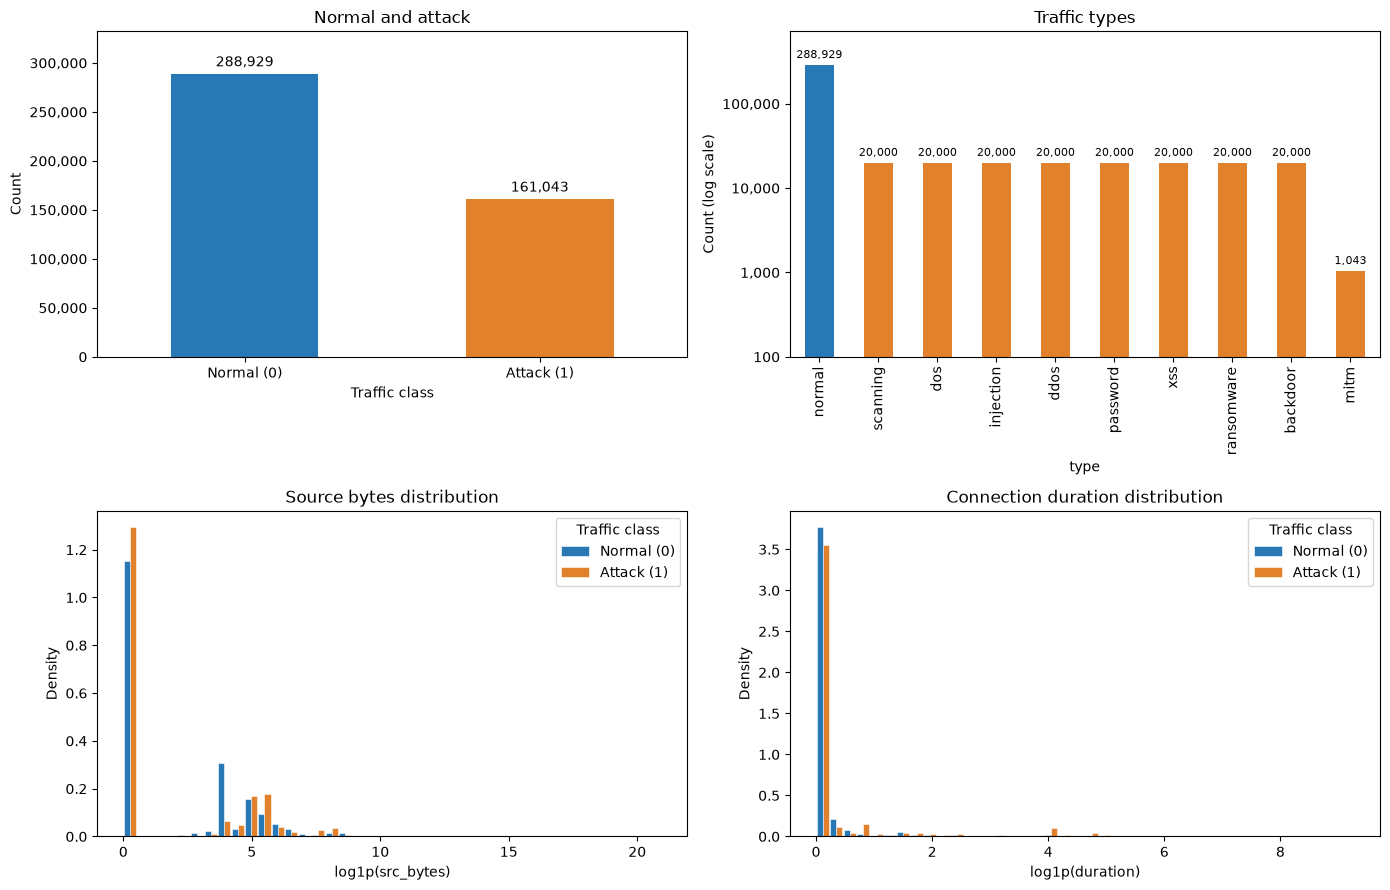

In [11]:
# 11.观察类别分布和两个长尾数值列的图形
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

palette = {"Normal (0)": "#2878B5", "Attack (1)": "#E1812C"}
view = df_dedup.groupby("label", group_keys=False).sample(n=5000, random_state=42)
view = view.assign(
    log_src_bytes=np.log1p(view["src_bytes"]),
    log_duration=np.log1p(view["duration"]),
    traffic_label=view["label"].map({0: "Normal (0)", 1: "Attack (1)"}),
)
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

label_counts = df_dedup["label"].value_counts().sort_index()
label_counts.plot.bar(
    ax=axes[0, 0], color=list(palette.values()), title="Normal and attack",
)
axes[0, 0].set_xticklabels(list(palette), rotation=0)
axes[0, 0].set_xlabel("Traffic class")
axes[0, 0].set_ylabel("Count")
axes[0, 0].set_ylim(0, label_counts.max() * 1.15)
axes[0, 0].bar_label(
    axes[0, 0].containers[0], labels=[f"{count:,}" for count in label_counts], padding=3,
)

type_counts = df_dedup["type"].value_counts()
type_counts.plot.bar(
    ax=axes[0, 1],
    color=[palette["Normal (0)"] if kind == "normal" else palette["Attack (1)"]
           for kind in type_counts.index],
    title="Traffic types",
)
axes[0, 1].set_yscale("log")
axes[0, 1].set_ylim(100, type_counts.max() * 2.5)
axes[0, 1].set_ylabel("Count (log scale)")
axes[0, 1].minorticks_off()
axes[0, 1].bar_label(
    axes[0, 1].containers[0], labels=[f"{count:,}" for count in type_counts],
    padding=3, fontsize=8,
)
for ax in axes[0]:
    ax.yaxis.set_major_formatter(FuncFormatter(lambda value, position: f"{value:,.0f}"))

for ax, field, title in [
    (axes[1, 0], "log_src_bytes", "Source bytes distribution"),
    (axes[1, 1], "log_duration", "Connection duration distribution"),
]:
    sns.histplot(
        data=view, x=field, hue="traffic_label",
        hue_order=list(palette), palette=palette, bins=40,
        stat="density", common_norm=False, multiple="dodge", shrink=0.9,
        alpha=1, edgecolor="white", linewidth=0.4, ax=ax,
    )
    ax.set_title(title)
    ax.get_legend().set_title("Traffic class")
axes[1, 0].set_xlabel("log1p(src_bytes)")
axes[1, 1].set_xlabel("log1p(duration)")
fig.tight_layout()
plt.show()

结论：全量去重数据中，正常流量有 288,929 行，攻击流量有 161,043 行。各攻击类型的数量并不完全相同，mitm 只有 1,043 行。右上图采用对数纵轴，并在柱上标出实际数量，使少数类型也能被看清。下面两图每类各抽 5,000 行，蓝色表示正常流量，橙色表示攻击流量，同一区间的柱子并排显示。源端字节和连接时长在零附近都有明显聚集，正常与攻击的分布也有重叠。所以不能靠其中一列或一张图判断模型能否识别攻击。等量抽样图只比较形状，不能用于估计总体比例，`log1p` 也没有改写训练数据。

总结：
01 现在已经确认了标签、`-`、重复记录、`weird` 和长尾。02笔记会从原始 CSV 重新读取，先去重并剔除环境标识，根据各列的含义处理`-`，分层划分后检查输入组合重叠，再只用训练集拟合编码与缩放。